In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

## Data Collection

In [3]:
data=pd.read_csv(r'datasets/banking.csv')

In [4]:
data.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1
5,30,management,divorced,basic.4y,no,yes,no,cellular,jul,tue,...,8,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,0
6,37,blue-collar,married,basic.4y,no,yes,no,cellular,may,thu,...,1,999,0,nonexistent,-1.8,92.893,-46.2,1.327,5099.1,0
7,39,blue-collar,divorced,basic.9y,no,yes,no,cellular,may,fri,...,1,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0
8,36,admin.,married,university.degree,no,no,no,cellular,jun,mon,...,1,3,1,success,-2.9,92.963,-40.8,1.266,5076.2,1
9,27,blue-collar,single,basic.4y,no,yes,no,cellular,apr,thu,...,2,999,1,failure,-1.8,93.075,-47.1,1.410,5099.1,0


In [13]:
data=data.dropna()

In [14]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

## EDA and PreProcessing

In [15]:
data['education'].unique()

array(['Basic', 'unknown', 'university.degree', 'high.school',
       'professional.course', 'illiterate'], dtype=object)

In [16]:
data['education']=data["education"].replace({'basic.4y':'Basic','basic.9y':'Basic','basic.6y':'Basic'})

In [18]:
data['education'].unique()

array(['Basic', 'unknown', 'university.degree', 'high.school',
       'professional.course', 'illiterate'], dtype=object)

In [19]:
data.value_counts('y')

y
0    36548
1     4640
Name: count, dtype: int64

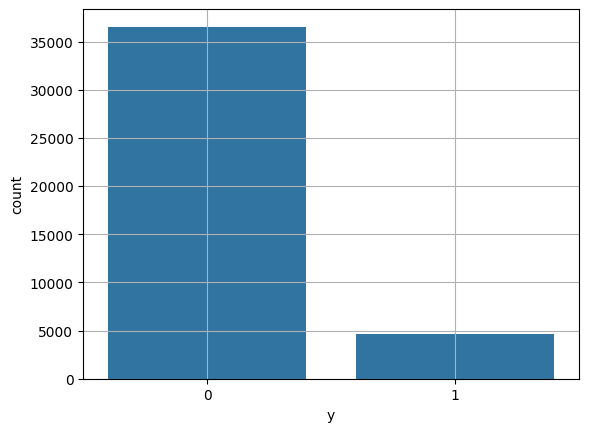

In [24]:
plt.Figure(figsize=(4,3))
sns.countplot(x='y',data=data)
plt.grid(True)
plt.show()

In [26]:
data.groupby('y').mean(numeric_only=True)

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
y,,,,,,,,,,
0,39.911185,220.844807,2.633085,984.113878,0.132374,0.248875,93.603757,-40.593097,3.811491,5176.166600
1,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991


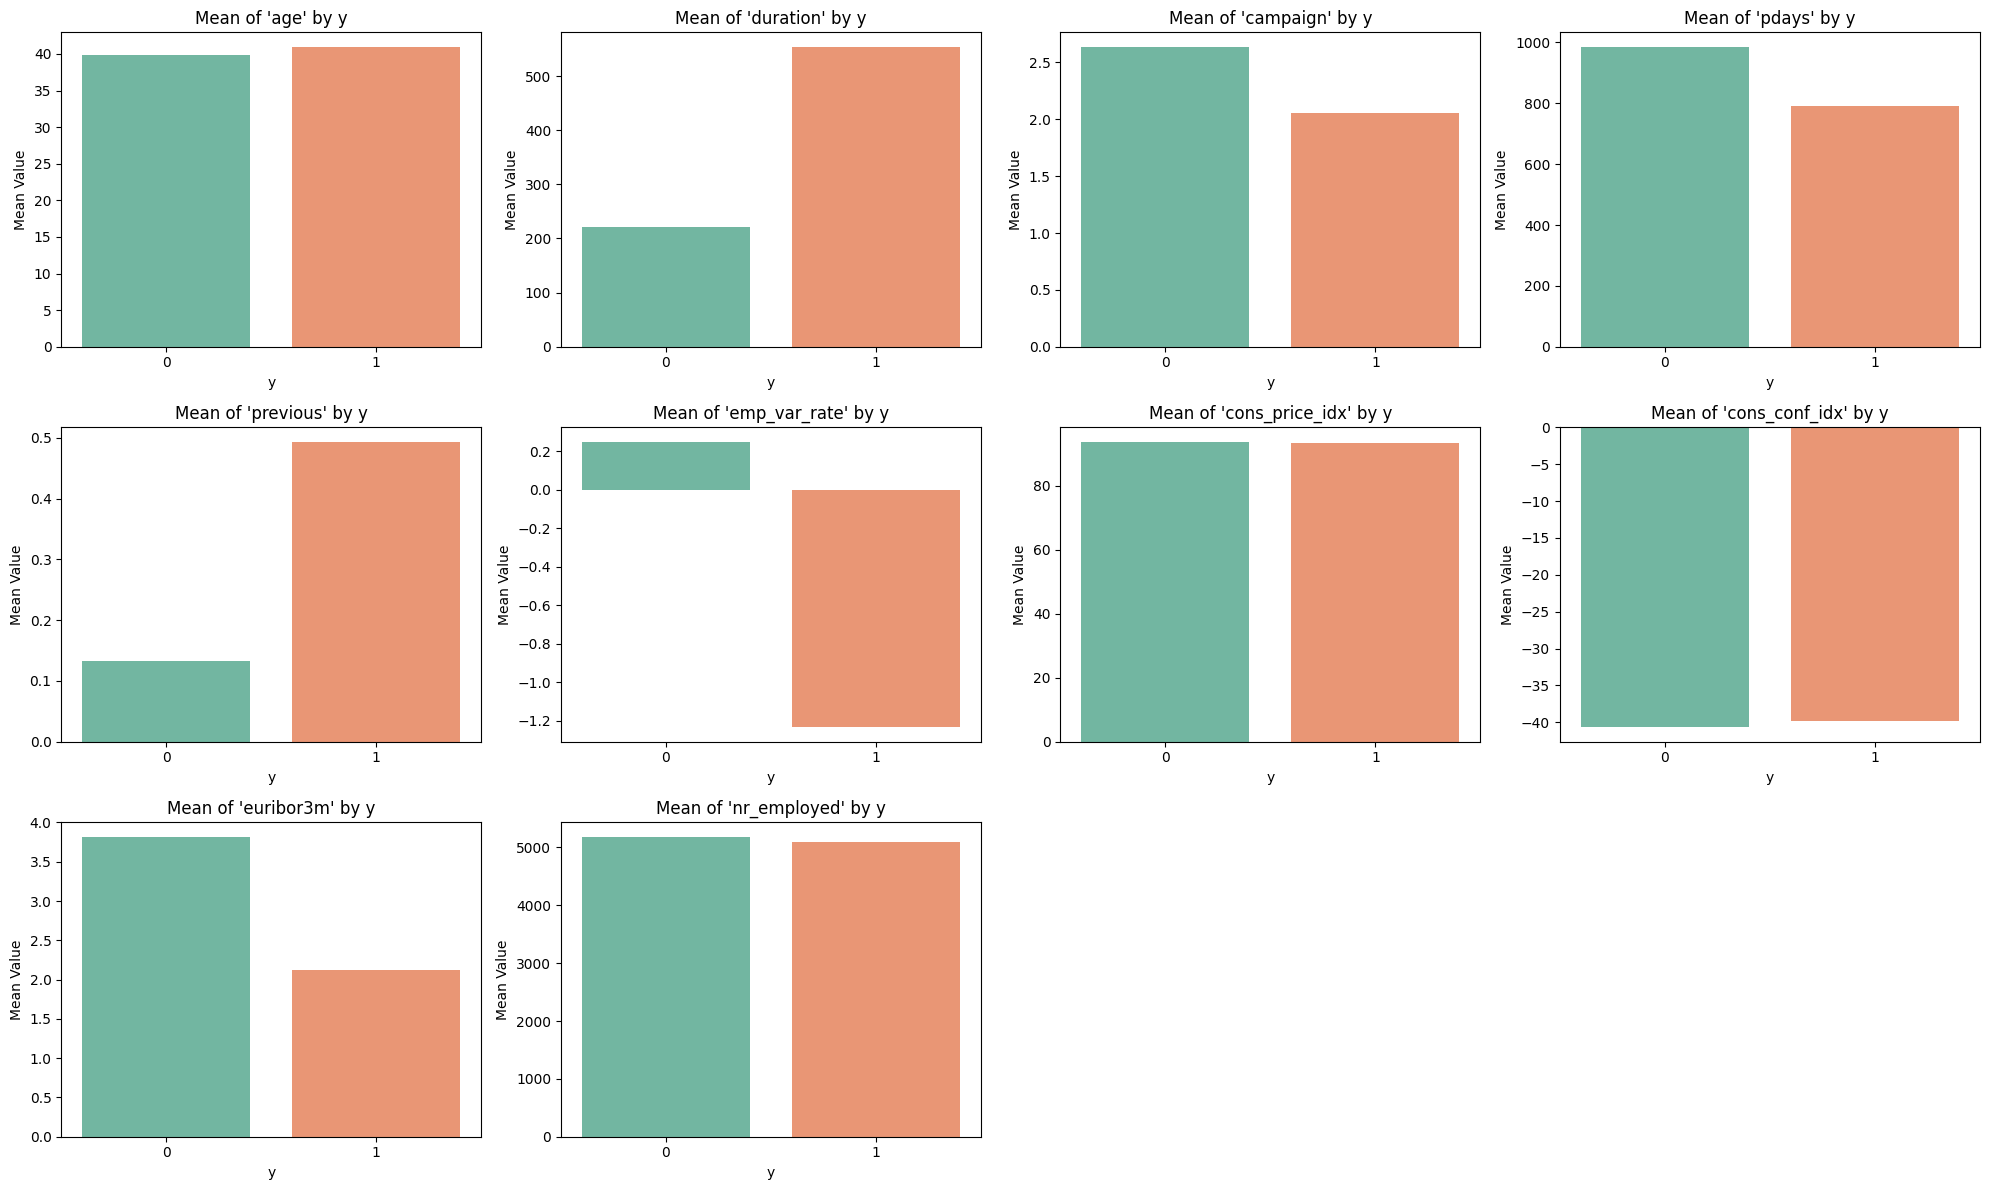

In [28]:
import math
import warnings 
warnings.filterwarnings('ignore')


grouped_means = data.groupby('y').mean(numeric_only=True).T
grouped_means = grouped_means.reset_index().melt(id_vars='index', var_name='y', value_name='mean_value')
grouped_means.rename(columns={'index': 'feature'}, inplace=True)

features = grouped_means['feature'].unique()

n_cols = 4
n_rows = math.ceil(len(features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.barplot(
        data=grouped_means[grouped_means['feature'] == feature],
        x='y',
        y='mean_value',
        ax=axes[i],
        palette='Set2'
    )
    axes[i].set_title(f"Mean of '{feature}' by y")
    axes[i].set_xlabel("y")
    axes[i].set_ylabel("Mean Value")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

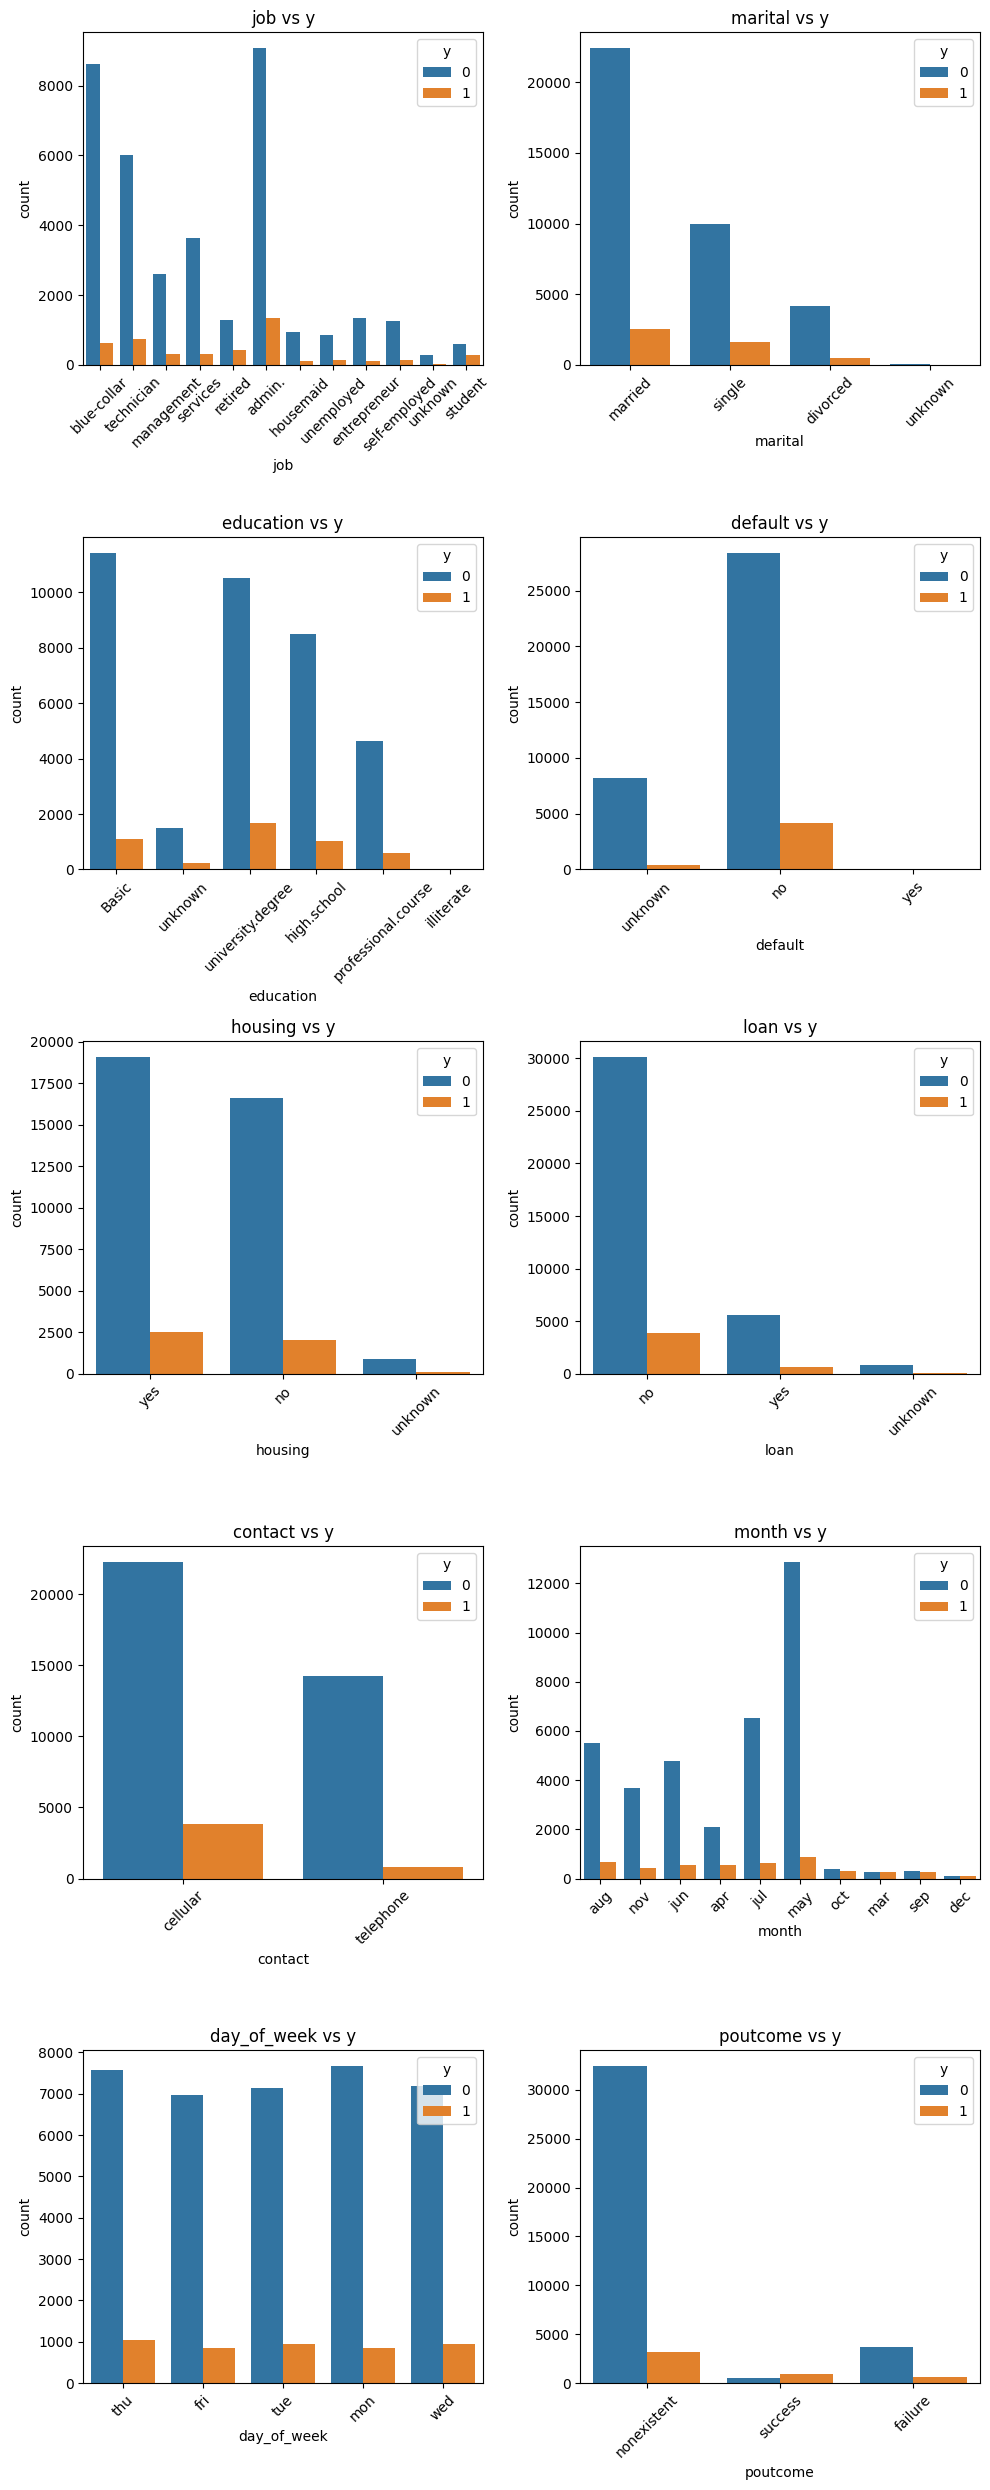

In [35]:
# Plotting the categorical column

categorical_cols = ['job', 'marital', 'education', 
                    'default', 'housing', 'loan', 'contact',
                    'month', 'day_of_week', 'poutcome']


n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=data, x=col, hue='y', ax=axes[i])
    axes[i].set_title(f'{col} vs y')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [36]:
def getDummies(df, category_cols):
    for col in category_cols:
        dummy_df = pd.get_dummies(df[col], drop_first=True, dtype='int')
        new_col_map = {c: f"{col}_{c}" for c in dummy_df.columns}
        dummy_df.rename(columns=new_col_map,inplace=True)
        df = pd.concat([df,dummy_df],axis=1)
    df.drop(category_cols,axis=1,inplace=True)
    return df

In [37]:
df_bank_1 = getDummies(df=data, category_cols=categorical_cols)

In [38]:
df_bank_1.head(10)

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,44,210,1,999,0,1.4,93.444,-36.1,4.963,5228.1,...,0,0,0,0,0,1,0,0,1,0
1,53,138,1,999,0,-0.1,93.200,-42.0,4.021,5195.8,...,0,1,0,0,0,0,0,0,1,0
2,28,339,3,6,2,-1.7,94.055,-39.8,0.729,4991.6,...,0,0,0,0,0,1,0,0,0,1
3,39,185,2,999,0,-1.8,93.075,-47.1,1.405,5099.1,...,0,0,0,0,0,0,0,0,1,0
4,55,137,1,3,1,-2.9,92.201,-31.4,0.869,5076.2,...,0,0,0,0,0,0,0,0,0,1
5,30,68,8,999,0,1.4,93.918,-42.7,4.961,5228.1,...,0,0,0,0,0,0,1,0,1,0
6,37,204,1,999,0,-1.8,92.893,-46.2,1.327,5099.1,...,1,0,0,0,0,1,0,0,1,0
7,39,191,1,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,1,0,0,0,0,0,0,0,1,0
8,36,174,1,3,1,-2.9,92.963,-40.8,1.266,5076.2,...,0,0,0,0,1,0,0,0,0,1
9,27,191,2,999,1,-1.8,93.075,-47.1,1.410,5099.1,...,0,0,0,0,0,1,0,0,0,0


In [39]:
X=df_bank_1
y=df_bank_1.pop('y')

## Model Building

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [44]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

y_pred=lr.predict(X_test)

In [45]:
y_pred

array([0, 0, 1, ..., 0, 0, 1], shape=(8238,))

## Evaluation of the matrix

In [ ]:
from sklearn.metrics import accuracy_score

In [51]:
accuracy=accuracy_score(y_test,y_pred)

print(round(accuracy,2))

0.91
